#**Setting up the Environment**

In [1]:
#Mounting
from google.colab import files
uploaded = files.upload()

Saving Aura_Final.csv to Aura_Final.csv


In [24]:
import pandas as pd
import numpy as np
from scipy.stats import randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

#**Creating Data Frame**

In [3]:
#Creating Baseline_Inventory1 data frame
df = pd.read_csv('Aura_Final.csv')
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,1,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,$29.85,$29.85,0
1,5575-GNVDE,0,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,$56.95,"$1,889.50",0
2,3668-QPYBK,0,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,$53.85,$108.15,1
3,7795-CFOCW,0,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),$42.30,"$1,840.75",0
4,9237-HQITU,1,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,$70.70,$151.65,1


#**Light Cleaning and Investigation**
Even though we inspected and cleaned the data in Excel it is important to double check that the data mounted into the Colab notebook correctly

In [4]:
#Reviewing columns with text
text_columns = df.select_dtypes(include=['object']).columns
print(text_columns)

Index(['customer_id', 'internet_service', 'contract', 'payment_method',
       'monthly_charges', 'total_charges'],
      dtype='object')


In [5]:
#Stripping extra spaces
#Precautionary measure
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [6]:
#Updating dataset
df.to_csv('Aura_Final.csv', index=False)

In [7]:
#Reviewing data frame shape for consistency
df.shape

(7043, 21)

In [8]:
#Reviewing counts and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        7043 non-null   object
 1   gender             7043 non-null   int64 
 2   senior_citizen     7043 non-null   int64 
 3   partner            7043 non-null   int64 
 4   dependents         7043 non-null   int64 
 5   tenure             7043 non-null   int64 
 6   phone_service      7043 non-null   int64 
 7   multiple_lines     7043 non-null   int64 
 8   internet_service   7043 non-null   object
 9   online_security    7043 non-null   int64 
 10  online_backup      7043 non-null   int64 
 11  device_protection  7043 non-null   int64 
 12  tech_support       7043 non-null   int64 
 13  streaming_tv       7043 non-null   int64 
 14  streaming_movies   7043 non-null   int64 
 15  contract           7043 non-null   object
 16  paperless_billing  7043 non-null   int64 


In [9]:
#Noticed that monthly_charges and total_charges are object data types
#Converting them into float data types
for col in ['monthly_charges', 'total_charges']:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False)
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
#Filling nulls with 0 (safety buffer)
df['total_charges'] = df['total_charges'].fillna(0)

#Double checking data type conversions
print(df[['monthly_charges', 'total_charges']].dtypes)

monthly_charges    float64
total_charges      float64
dtype: object


In [11]:
#Reviewing basic statistical data
df.describe()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


In [12]:
#Data type count
pd.value_counts(df.dtypes)

/tmp/ipykernel_3847/3293345760.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.dtypes)


,count
int64,15
object,4
float64,2


In [13]:
#Evaluating categorical features
df.select_dtypes(exclude="number").head()

,customer_id,internet_service,contract,payment_method
0,7590-VHVEG,DSL,Month-to-month,Electronic check
1,5575-GNVDE,DSL,One year,Mailed check
2,3668-QPYBK,DSL,Month-to-month,Mailed check
3,7795-CFOCW,DSL,One year,Bank transfer (automatic)
4,9237-HQITU,Fiber optic,Month-to-month,Electronic check


/tmp/ipykernel_3847/3388559593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x=unique_values.index, y=unique_values, palette='inferno')
/tmp/ipykernel_3847/3388559593.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')


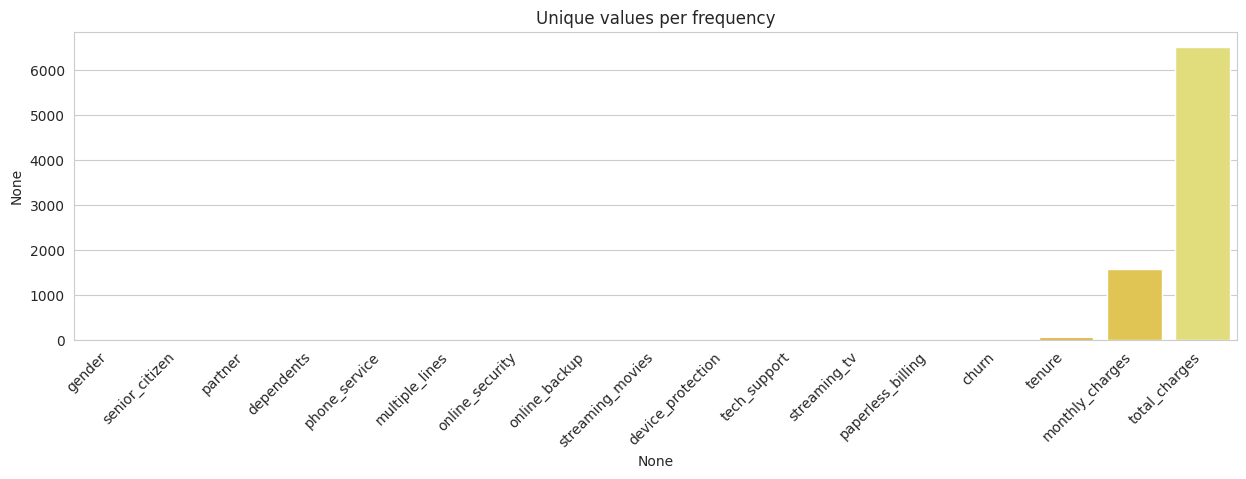

In [14]:
#Evaluation of Numeric Features
unique_values = df.select_dtypes(include='number').nunique().sort_values()
plt.figure(figsize=(15, 4))
sns.set_style('whitegrid')

g = sns.barplot(x=unique_values.index, y=unique_values, palette='inferno')
g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
g.set_title('Unique values per frequency')
plt.show()

#**Supervised Classification - Random Forest**
Using random forest to predict churn. Since this dataset is not a "Big Data" dataset, implementing random forest will not be computationally heavy and is a better option than a single decision tree model as it is better at normalization and overfitting issues.

In [15]:
#Creating x and y splits
customer_ids = df['customer_id']
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

In [16]:
#Creating dummies
X_encoded = pd.get_dummies(X, drop_first=True)

In [17]:
#Splitting the data into training and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
#Scaling numeric columns
scaler = StandardScaler()
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [21]:
#Hyperparameter tuning prep
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 11),
    'min_samples_split': randint(2, 21),
    'min_samples_leaf': randint(1, 9),
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

In [22]:
#Executing and evaluating model
rand_search.fit(X_train, y_train)

best_rf = rand_search.best_estimator_
print(rand_search.best_params_)

y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))

{'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 406}
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



Classification Report:

Class 0 (Non Churners) - For the most part the model is very good at recognizing customers who will stay with a precision of 0.91 and a recall of 0.76. An F1 score of 0.83 indicates a strong overall performance for Class 0.

Class 1 (Churners) - The model is solid when it comes to catching churners with a recall of 0.78 but lacks a bit with a precision of 0.54. Seems to be the trade off of having a solid recall of 0.78 in a churning scenario. F1 score is a solid balance at 0.64.

The model predicted 78% of all customers who actually churned (Class 1 recall) which could be considered the “trade-off” for the low precision score of 54% when keeping in mind that catching churners is more important than avoiding false alarms.


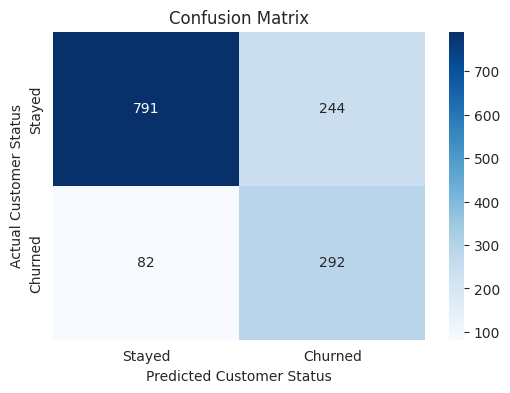

In [49]:
#Evaluating Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual Customer Status')
plt.xlabel('Predicted Customer Status')
plt.show()

Confusion Matrix:

*   True Negatives: The model correctly identified 791 customers who stayed
*   True Positive: The model correctly identified 292 customers who churned
*   False Negatives: The model incorrectly identified 82 churners as non-churners
*   False Positives: The model incorrectly identified 244 non-churners as churners

##Random Forest Summary
The recall vs precision trade-off is acceptable in this scenario as we are looking to catch churners rather than miss them. It is a solid model all-around. We will now further assess the model by examining the feature importance weight.

#**Feature Importance Weight Validation**
Assessing the weight distribution for the features used in our Random Forest model

In [27]:
#Extracting feature importance scores
importances = best_rf.feature_importances_

In [28]:
#Matching scores with features
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

In [29]:
#Sorting features in descending order
sorted_importances = forest_importances.sort_values(ascending=False)

In [30]:
#Reviewing top 10 feature importance weight
print("Top 10 Feature Importance Weight")
for rank, (feature, score) in enumerate(sorted_importances.head(10).items(), 1):
    print(f"{rank}. {feature:<30} | Weight: {score:.4f} ({score*100:.2f}%)")

Top 10 Feature Importance Weight
1. tenure                         | Weight: 0.1753 (17.53%)
2. total_charges                  | Weight: 0.1322 (13.22%)
3. contract_Two year              | Weight: 0.1244 (12.44%)
4. monthly_charges                | Weight: 0.1135 (11.35%)
5. internet_service_Fiber optic   | Weight: 0.0969 (9.69%)
6. payment_method_Electronic check | Weight: 0.0597 (5.97%)
7. contract_One year              | Weight: 0.0473 (4.73%)
8. internet_service_No            | Weight: 0.0468 (4.68%)
9. online_security                | Weight: 0.0282 (2.82%)
10. paperless_billing              | Weight: 0.0259 (2.59%)


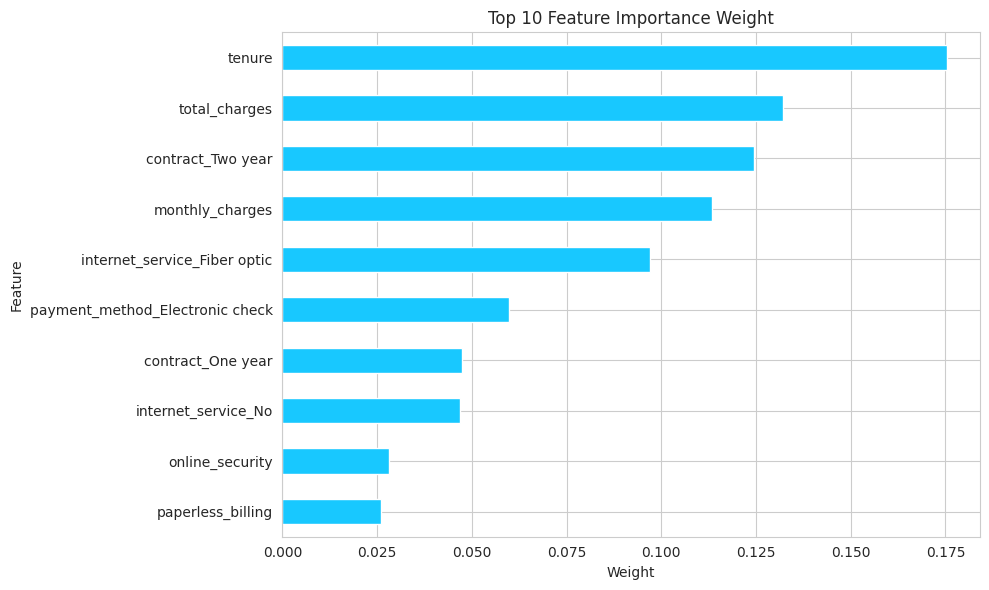

In [31]:
#Visualizing feature importance weight
plt.figure(figsize=(10, 6))
sorted_importances.head(10).plot(kind='barh', color='#18C8FF')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance Weight')
plt.xlabel('Weight')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##Feature Importance Weight Summary
Given the context of project and upon further examination of the features it looks as if the weight distribution is fairly reasonable for each feature. We will now proceed with implementing at-risk predictions for each customer in the dataset.

#**At-Risk Predictions**
Predicting churn probability and computing at-risk revenue

In [32]:
#Scaling numeric features
X_full_scaled = X_encoded.copy()
X_full_scaled[numeric_cols] = scaler.transform(X_encoded[numeric_cols])

In [33]:
#Predicting probability
full_probabilities = best_rf.predict_proba(X_full_scaled)[:, 1]

In [34]:
#Feature engineering
df['churn_probability'] = np.round(full_probabilities, 4)

In [35]:
#Calculating at_risk_revenue
df['at_risk_revenue'] = np.round(df['monthly_charges'] * df['churn_probability'], 2)

In [36]:
#Reviewing new features
print(df[['customer_id', 'monthly_charges', 'churn_probability', 'at_risk_revenue']].head())

  customer_id  monthly_charges  churn_probability  at_risk_revenue
0  7590-VHVEG            29.85             0.7199            21.49
1  5575-GNVDE            56.95             0.1112             6.33
2  3668-QPYBK            53.85             0.6872            37.01
3  7795-CFOCW            42.30             0.0851             3.60
4  9237-HQITU            70.70             0.8481            59.96


#**Segmenting Customers With K Means Clustering**
We need to establish tiers for targeted marketing campaigns for at-risk cleintele. To accomplish this we need to segment the customers so that we can develop a customer retention strategy for each respective customer group. There is an industry standard that says anyone above a 90% probability of churning are "lost causes" so the first course of action is to filter out that 10% of "lost causes" before proceeding with the rest of the customer segmentation.

In [37]:
#Filtering for instances that are < 0.9 in churn_probability
#Creating a new data frame based on this filtration to export for future analysis
df_churn_prob = df[df['churn_probability'] < 0.9].copy()

In [38]:
#Reviewing data frame shape for consistency
#Two new columns since we initially imported the dataset (churn probability and at risk revenue)
df_churn_prob.shape

(6875, 23)

In [39]:
#Segmenting according to monthly charges
X = df_churn_prob[['monthly_charges']].values

In [40]:
#Initializing K Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_churn_prob['cluster_label'] = kmeans.fit_predict(X)

In [51]:
#Creating tier structure
cluster_means = df_churn_prob.groupby('cluster_label')['monthly_charges'].mean().sort_values()
tier_mapping = {
    cluster_means.index[0]: 'Tier 1 (Low)',
    cluster_means.index[1]: 'Tier 2 (Medium)',
    cluster_means.index[2]: 'Tier 3 (High)'
}
df_churn_prob['tier'] = df_churn_prob['cluster_label'].map(tier_mapping)

In [44]:
#Reviewing results
summary = df_churn_prob.groupby('tier')['monthly_charges'].agg(['count', 'min', 'max', 'mean']).round(2)
print(summary)

                 count    min     max   mean
tier                                        
Tier 1 (Low)      1890  18.25   42.30  23.36
Tier 2 (Medium)   2179  42.35   77.75  61.32
Tier 3 (High)     2806  77.80  118.75  94.22


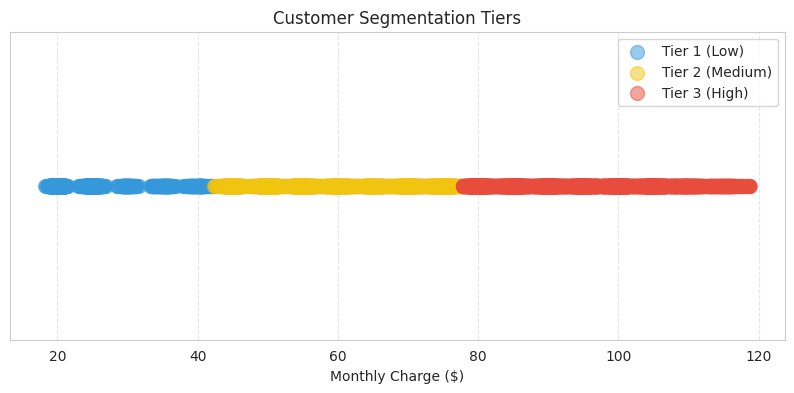

In [46]:
#Visualizing clusters
plt.figure(figsize=(10, 4))
colors = {'Tier 1 (Low)': '#3498db', 'Tier 2 (Medium)': '#f1c40f', 'Tier 3 (High)': '#e74c3c'}

for tier, group in df_churn_prob.groupby('tier'):
    plt.scatter(group['monthly_charges'], [0] * len(group), label=tier, color=colors[tier], alpha=0.5, s=100)

plt.title('Customer Segmentation Tiers')
plt.xlabel('Monthly Charge ($)')
plt.yticks([])  # Hide y-axis since it is 1D data
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [48]:
#Reviewing data frame shape for consistency
#Two new columns since we initially imported the dataset (cluster_label and tier)
df_churn_prob.shape

(6875, 25)

In [47]:
#Exporting updated data
output_filename = 'Aura_Churn_Prob.csv'
df_churn_prob. to_csv(output_filename, index=False)

##K Means Clustering Summary


*   Tier 1 (Low): These are the customers who spend the least on monthly charges. There are 1,890 customers who belong to this tier. They have a minimum of monthly charge value of 18.25, a maximum of 42.30, with an average of 23.36.
*   Tier 2 (Medium): These are the customers who spend the medium amount of money on monthly charges out of the entire dataset. There are 2,179 customers who belong to this tier. They have a minimum of monthly charge value of 42.35, a maximum of 77.75 with an average of 61.32.
*   Tier 3 (High): These are the customers who spend the most on monthly charges. There are 2,806 customers who belong to this tier. They have a minimum of monthly charge value of 77.80, a maximum of 118.75, with an average of 94.22.

Now that we have 90% of customer base segmented, we will now export the data from this workbook into SQL for further investigation.


